# Loading and plotting CTR measurements

This tutorial uses the preferred metadata-aware CTR API. A `CTR` stores one rod, while `MeasurementReduction` states whether its values are structure factors or reflectivity. `PolarizationReduction` records the incident mixture, outgoing analysis, and—when applicable—the conventional intensity correction factor $P$.

The metadata is part of the measurement: keep it with the values when loading, selecting, copying, plotting, or writing NeXus data. Do not infer polarization provenance from the rod indices or numerical values.


In [1]:
%matplotlib inline
from pathlib import Path
from tempfile import TemporaryDirectory
import sys

import matplotlib.pyplot as plt
from silx.io.dictdump import dicttonx, nxtodict


def _find_repository_root():
    """Return the checkout containing this documentation notebook."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "orgui" / "datautils").is_dir():
            return candidate
    return None


repository_root = _find_repository_root()
if repository_root is not None and "orgui" not in sys.modules:
    sys.path.insert(0, str(repository_root))

from orgui.datautils.xrayutils.CTRplotutil import (  # noqa: E402
    CTR,
    CTRCollection,
    CTRFigure,
    MeasurementReduction,
    PolarizationReduction,
    ctrfigure,
)


## Preferred API: load reduced values with their metadata

The synthetic example is an orGUI CTR file: an ANAROD-like whitespace table with a small metadata comment header. It contains 300 points on each of two rods, spans $0.02 \leq L \leq 3.20$, and resolves the first three Bragg peaks.

The numerical columns keep the useful part of the ANAROD order, omit its unused `mode`, and append the new value: `H K L F_HKL errorF polarization_factor`. In a real workflow, replace the example path with the output of your reduction pipeline.

The scalar incident mixture and outgoing channel normally come from the beamline configuration or reduction record. Here the beam was 92% s-polarized in the local Renaud basis and the outgoing polarization was not analysed.


In [2]:
if repository_root is not None:
    data_path = repository_root / "doc/source/_static/ctr_measurement_example.ctr"
else:
    data_path = Path("_static/ctr_measurement_example.ctr")

measurements = CTRCollection.fromCTRFile(data_path)
len(measurements), sum(rod.l.size for rod in measurements)


(2, 600)

In [3]:
[
    (
        rod.hk,
        rod.reduction.quantity,
        rod.reduction.polarization.s_fraction,
        rod.reduction.polarization.outgoing,
        rod.reduction.polarization.polarization_factor.shape,
    )
    for rod in measurements
]


[((1.0, 0.0), 'structure_factor', 0.92, 'unanalysed', (300,)),
 ((2.0, 0.0), 'structure_factor', 0.92, 'unanalysed', (300,))]

## Plot with `CTRFigure`

Create CTR figures with `ctrfigure()`. The factory returns a `CTRFigure` registered correctly with Matplotlib. Add individual rods with `addCTR`, or apply one style to a collection with `CTRCollection.setPlotSettings` followed by `addCollection`. The y-axis label follows `MeasurementReduction.quantity`.


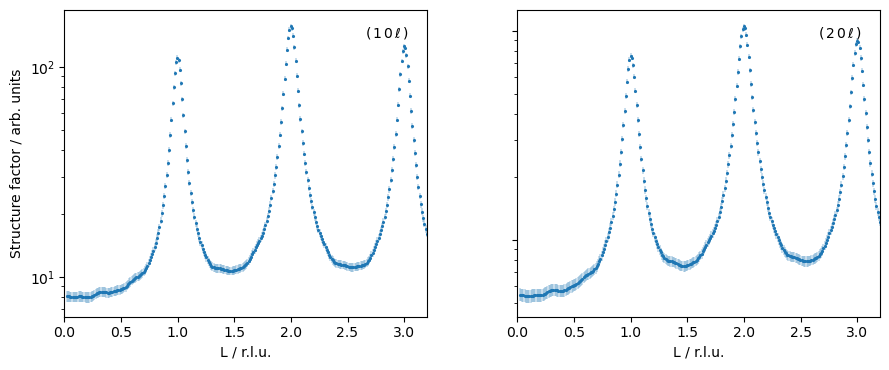

In [4]:
measurements.setPlotSettings(
    linestyle="",
    marker=".",
    markersize=2.5,
    elinewidth=0.35,
    color="tab:blue",
    zorder=2,
    xlim=(0.0, 3.2),
)

figure = ctrfigure(figsize=(9.0, 3.8))
assert isinstance(figure, CTRFigure)
figure.settings(wspace=0.25)
figure.addCollection(measurements)
figure.generateCTRplot(
    cols=2, rodlabel="topright", rodLabelL=True, share_axes=False
)
plt.show()


## Persist and load the complete measurement

Schema-2 NeXus persistence retains the quantity, polarization metadata, pointwise $P$, values, uncertainties, and optional geometry. The temporary round trip below is self-contained. For an existing file, the two loading lines are simply `payload = nxtodict(path)["entry"]` and `CTRCollection.fromNXdict(payload)`.


In [5]:
with TemporaryDirectory() as temporary_directory:
    nexus_path = Path(temporary_directory) / "reduced_ctrs.nxs"
    dicttonx({"entry": measurements.toNXdict()}, str(nexus_path))
    payload = nxtodict(str(nexus_path))["entry"]
    loaded_measurements = CTRCollection.fromNXdict(payload)

[
    (rod.hk, rod.reduction == source.reduction)
    for rod, source in zip(loaded_measurements, measurements)
]


[((1.0, 0.0), True), ((2.0, 0.0), True)]

### Reflectivity data

For corrected reflectivity, use `quantity="reflectivity"`. Keep the incident/outgoing polarization description, but do not attach `polarization_factor`: the stored values must already be corrected dimensionless $R$. Structure-factor-only consumers reject such rods instead of silently interpreting $R$ as $F$.


In [6]:
reflectivity_reduction = MeasurementReduction(
    quantity="reflectivity",
    polarization=PolarizationReduction(
        s_fraction=0.92, outgoing="unanalysed"
    ),
)
reflectivity = CTR(
    (0, 0),
    [0.02, 0.04, 0.06],
    [0.78, 0.42, 0.18],
    [0.02, 0.02, 0.01],
    reduction=reflectivity_reduction,
)
reflectivity.reduction


MeasurementReduction(quantity='reflectivity', polarization=PolarizationReduction(s_fraction=0.92, outgoing='unanalysed', polarization_factor=None))

## Make old ANAROD data metadata-compatible

ANAROD text files carry numerical columns but no measurement-reduction metadata. `CTRCollection.fromANAROD` therefore defaults to structure-factor data with unknown polarization provenance. That default remains suitable for legacy kinematical work, but it is not enough to reproduce a polarization-aware calculation.

If—and only if—the reduction provenance is known independently, pass it explicitly while importing. The tracked fixture below contains `H K L F_HKL phi mode`, so `RODexport=True` interprets column five as phase. For the common `H K L F_HKL errorF mode` layout, leave `RODexport=False` (the default).


In [7]:
if repository_root is None:
    raise RuntimeError("Run the legacy example from an orGUI checkout.")

anarod_path = (
    repository_root
    / "orgui/datautils/xrayutils/test/testdata/CTRs_reference.dat"
)

legacy_default = CTRCollection.fromANAROD(anarod_path, RODexport=True)
legacy_default[0].reduction


MeasurementReduction(quantity='structure_factor', polarization=None)

In [8]:
# Replace these values with the independently documented beamline/reduction
# provenance for the file. Here they mean pure local s incidence, an
# unanalysed exit, and no applied polarization correction (P = 1).
legacy_reduction = MeasurementReduction(
    quantity="structure_factor",
    polarization=PolarizationReduction(
        s_fraction=1.0,
        outgoing="unanalysed",
        polarization_factor=None,
    ),
)

legacy_compatible = CTRCollection.fromANAROD(
    anarod_path,
    RODexport=True,
    reduction=legacy_reduction,
    name="legacy ANAROD with explicit provenance",
)
legacy_compatible[0].reduction


MeasurementReduction(quantity='structure_factor', polarization=PolarizationReduction(s_fraction=1.0, outgoing='unanalysed', polarization_factor=None))

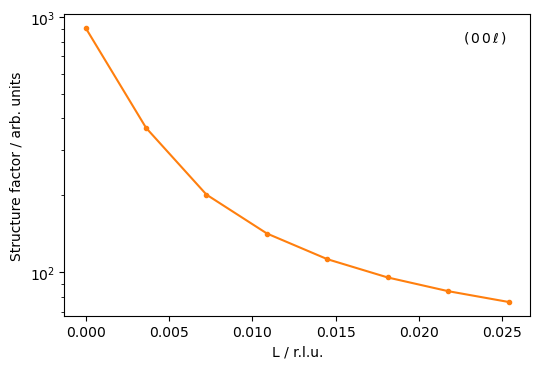

In [9]:
legacy_compatible.setPlotSettings(
    linestyle="-", marker=".", color="tab:orange", zorder=2
)
legacy_figure = ctrfigure(figsize=(5.5, 3.8))
legacy_figure.addCollection(legacy_compatible)
legacy_figure.generateCTRplot(
    cols=1, rodlabel="topright", rodLabelL=True, share_axes=False
)
plt.show()


### Legacy migration checklist

1. Confirm whether the fourth column is $F$, corrected $R$, or an intensity that still needs conversion.
2. Confirm whether column five is `errorF` or phase and select `RODexport` accordingly.
3. Recover `s_fraction`, `outgoing`, and any row-aligned conventional factor $P$ from trustworthy beamline or reduction records.
4. Import with `reduction=...`; if provenance is unavailable, retain `MeasurementReduction()` instead of guessing.
5. Write the collection to schema-2 NeXus so subsequent loads recover the metadata automatically.
